In [ ]:
# Ignore the warnings
import warnings
# warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# System related and data input controls
import os

# Python path
import sys
base_folder = 'DataScience'
location_base = os.path.join(os.getcwd().split(base_folder)[0], base_folder)
location_module = [os.path.join(location_base, 'Module')] 
for each in location_module:
    if each not in sys.path:
        sys.path.append(each)

# Auto reload of library
%reload_ext autoreload
%autoreload 2

from import_KK import *
DeviceStrategy_CPU()
# DeviceStrategy_GPU()
from preprocessing_KK import *
from preprocessing_project_KK import *
from description_KK import *
from algorithm_machinelearning_KK import *
from algorithm_deeplearning_KK import *
from evaluation_KK import *
from visualization_KK import *

JAVA is in the system path?:  False
JAVA is in the system path?:  Adding...
Operation Machine:  Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
Operation Platform:  64bit
OS Type:  Windows
OS Version:  11
Python Version:  3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]



# Result (Prediction)

In [47]:
# Data Loading
file_location = os.path.join('.', 'Result', 'Prediction_KK.csv')
df = pd.read_csv(file_location)
# Filtering
df = df[df.Date>='2024-02-01'].reset_index().iloc[:,1:]
# Output
df_baseline1 = df.loc[(df.Lookback == 5) & (df['Feature Case'] == 'Macro Only') & (df.Model == 'GRU')].reset_index().iloc[:,1:]
df_baseline2 = df.loc[(df.Lookback == 20) & (df['Feature Case'] == 'Macro Only') & (df.Model == 'GRU')].reset_index().iloc[:,1:]
df_final = df.loc[(df.Lookback == 20) & (df['Feature Case'] == 'Macro + Event + Sentiment (Both)') & (df.Model == 'CNN-GRU')].reset_index().iloc[:,1:]
# Setting
df_line.Date = pd.to_datetime(df_line.Date)
df_line.set_index('Date', inplace=True)
df_line

,Y True,Y Pred(base1),Y Pred(base2),Y Pred(best)
Date,,,,
2024-02-01,"1,328.9500","1,333.1329","1,333.6892","1,333.8860"
2024-02-02,"1,337.7600","1,328.0110","1,329.1089","1,329.3270"
2024-02-05,"1,333.1300","1,336.4458","1,337.8497","1,338.5504"
2024-02-06,"1,326.8700","1,331.6085","1,333.2559","1,334.1456"
2024-02-07,"1,328.2900","1,325.3331","1,327.1897","1,328.0836"
...,...,...,...,...
2024-12-20,"1,444.5700","1,441.3127","1,443.2894","1,445.9564"
2024-12-23,"1,451.2800","1,441.1289","1,443.0248","1,445.9357"
2024-12-24,"1,458.9300","1,447.8973","1,450.2180","1,452.4991"


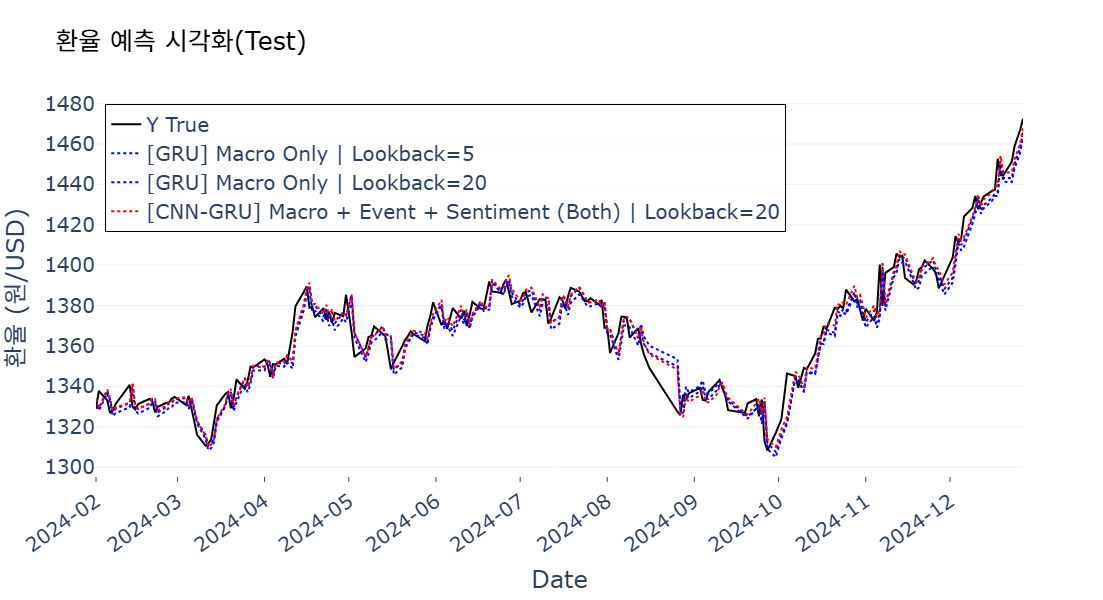

In [69]:
import plotly.graph_objects as go
import os
import pandas as pd

def plot_line(df, title='Line Plot', x_title='Date', y_title='Count',
              save_local=True, save_name='lineplot.png',
              name_map=None, color_map=None, style_map=None,
              legend_pos='top_left'): # legend_pos 인자 추가
    
    # 1. Date 변환
    if not pd.api.types.is_datetime64_any_dtype(df.index):
        try:
            df.index = pd.to_datetime(df.index)
        except:
            pass
    fig = go.Figure()

    # 데이터 Trace 추가 (이전과 동일)
    for col in df.columns:
        trace_name = name_map.get(col, col) if name_map else col
        line_color = color_map.get(col, None) if color_map else None
        line_dash = style_map.get(col, 'solid') if style_map else 'solid'
        fig.add_trace(go.Scatter(
            x=df.index, y=df[col], mode='lines', name=trace_name,
            line=dict(color=line_color, dash=line_dash)
        ))      

    # 2. Legend 위치 설정 로직
    # 기본값: 그래프 바깥 오른쪽 (Plotly 기본)
    legend_setting = {} 
    if legend_pos == 'top_left':
        legend_setting = dict(
            yanchor="top", y=0.99,   # 상단
            xanchor="left", x=0.01,  # 왼쪽
            bgcolor='rgba(255, 255, 255, 0.7)', # 흰색 배경 (70% 불투명)
            bordercolor="Black", borderwidth=1  # 테두리 (선택사항)
        )
    elif legend_pos == 'top_right':
        legend_setting = dict(
            yanchor="top", y=0.99,
            xanchor="right", x=0.99,
            bgcolor='rgba(255, 255, 255, 0.7)'
        )
    elif legend_pos == 'bottom_right':
        legend_setting = dict(
            yanchor="bottom", y=0.01,
            xanchor="right", x=0.99,
            bgcolor='rgba(255, 255, 255, 0.7)'
        )
    elif legend_pos == 'top_center_horizontal':
        legend_setting = dict(
            orientation="h",       # 가로 배치
            yanchor="bottom", y=1.02, # 그래프 바로 위
            xanchor="right", x=1
        )

    # Layout 설정
    fig.update_layout(
        xaxis_title=x_title, yaxis_title=y_title,
        width=1000, height=600,
        title=dict(text=title, font=dict(size=25, color='black')),
        font=dict(size=20),
        legend_font_size=20,
        template='plotly_white',
        # 여기서 legend 설정을 적용합니다.
        legend=legend_setting 
    )

    # X축 설정 (이전과 동일)
    fig.update_xaxes(
        tickangle=-35, tickfont=dict(size=20), ticks='outside', showgrid=False,
        tickformat="%Y-%m", dtick="M1"
    )
    fig.update_yaxes(showgrid=True)
    fig.show()

    # Save
    if save_local:
        folder_location = os.path.join(os.getcwd(), 'Result', 'Lineplot')
        os.makedirs(folder_location, exist_ok=True)
        save_path = os.path.join(folder_location, save_name)
        # fig.write_image(save_path, engine='kaleido')
        print(f"Saved to {save_path}")

my_names = {
    'Y True': 'Y True',
    'Y Pred(base1)': '[GRU] Macro Only | Lookback=5',
    'Y Pred(base2)': '[GRU] Macro Only | Lookback=20',
    'Y Pred(best)': '[CNN-GRU] Macro + Event + Sentiment (Both) | Lookback=20'
}
my_colors = {
    'Y True': 'black',       # 실제값은 검정
    'Y Pred(base1)': 'blue', # 베이스 모델은 회색
    'Y Pred(base2)': 'blue', 
    'Y Pred(best)': 'red'    # 베스트 모델은 빨강 강조
}
my_styles = {
    'Y True': 'solid',
    'Y Pred(base1)': 'dot',  # 점선
    'Y Pred(base2)': 'dot',
    'Y Pred(best)': 'dot'
}
plot_line(
    df_line, title='환율 예측 시각화(Test)', y_title='환율 (원/USD)', 
    legend_pos='top_left',
    name_map=my_names, 
    color_map=my_colors, 
    style_map=my_styles,
    save_local=False
)

# Result (Evaluation)

In [2]:
# Hyperparameters
METRIC_COLNAMES = ["RMSE", "MSPE", "MAE", "MAPE", "MedAE", "MedAPE"]
LABEL_COLNAME = "Model & Feature Case"
SCALING = True
TOP_RANKING = 10

In [3]:
# Data Loading
file_location = os.path.join('.', 'Result', 'PerformanceEvaluation_20260129_KK.xlsx')
df = pd.read_excel(file_location, sheet_name='Total')
df['Model & Feature Case'] = '[' + df.Model + ']  ' + df['Feature Case']
df = df[[col for col in df.columns if col != 'Radar Chart']]


Top 10 by Radar Area:


,Model & Feature Case,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,Area of Radar
0,[GRU] Macro + Event + Sentiment (Both),0.9343,0.9327,0.9692,0.9676,1.0000,1.0000,2.4315
1,[CNN-GRU] Macro + Event + Sentiment (Direct),0.9677,0.9674,0.9709,0.9708,0.9059,0.9187,2.3463
2,[CNN-GRU] Macro + Sentiment (Both),1.0000,0.9981,1.0000,1.0000,0.8133,0.8533,2.3196
3,[LSTM] Macro + Event + Sentiment (Both),0.9743,0.9694,0.9734,0.9724,0.9031,0.8363,2.2877
4,[CNN-GRU] Macro + Sentiment (Indirect),0.9587,0.9581,0.9649,0.9647,0.8825,0.8109,2.2163
5,[CNN-GRU] Macro Only,0.9505,0.9495,0.9499,0.9499,0.8004,0.9158,2.1958
6,[CNN-GRU] Macro + Event,0.9088,0.9171,0.9388,0.9421,0.9301,0.8628,2.1832
7,[CNN-LSTM] Macro + Sentiment (Both),0.9840,0.9839,0.9823,0.9831,0.7694,0.7623,2.1622
8,[LSTM] Macro + Event,0.9619,0.9610,0.9981,0.9983,0.7402,0.7492,2.1193
9,[CNN-LSTM] Macro + Event,0.9567,0.9550,0.9778,0.9771,0.7212,0.7913,2.0937


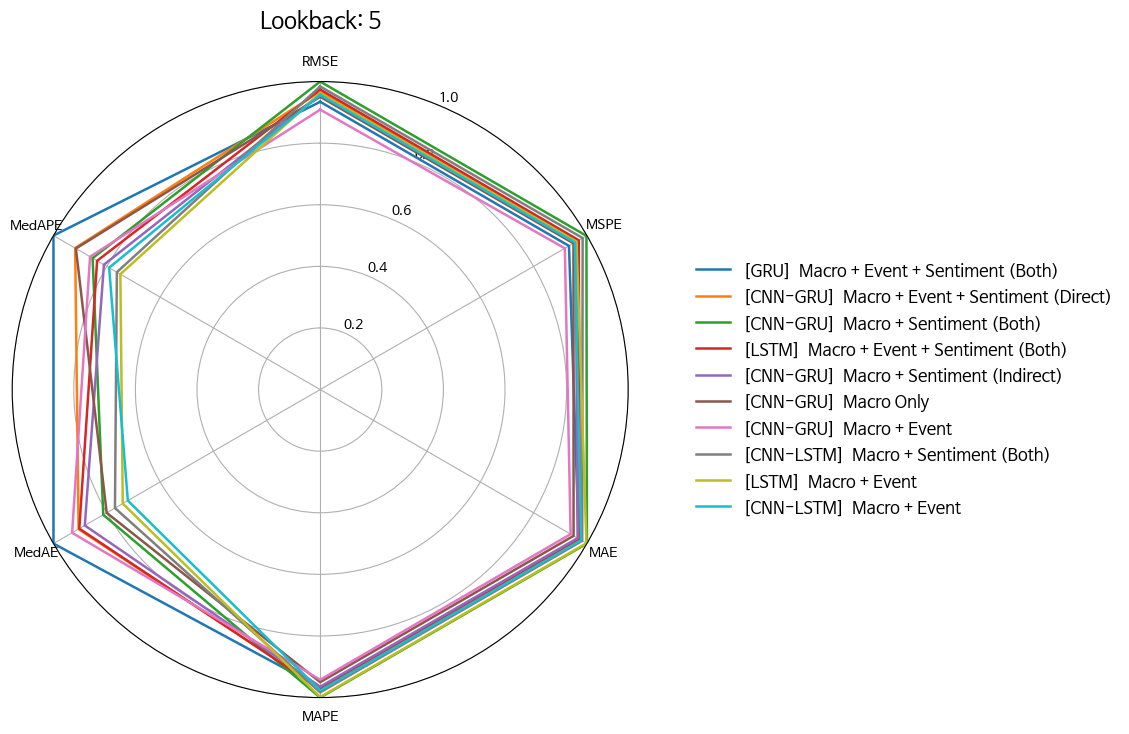


Top 10 by Radar Area:


,Model & Feature Case,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,Area of Radar
0,[LSTM] Macro + Event + Sentiment (Both),0.8885,0.8740,0.9390,0.9298,1.0000,1.0000,2.2901
1,[CNN-GRU] Macro + Event + Sentiment (Indirect),0.9327,0.9266,0.9823,0.9783,0.7858,0.8623,2.1590
2,[CNN-GRU] Macro + Sentiment (Indirect),0.8830,0.8800,0.8925,0.8875,0.8356,0.9162,2.0225
3,[CNN-GRU] Macro + Event + Sentiment (Both),1.0000,1.0000,0.9750,0.9729,0.7354,0.5906,2.0196
4,[CNN-LSTM] Macro + Event + Sentiment (Both),0.8753,0.8892,0.8391,0.8428,0.9458,0.8822,2.0071
5,[CNN-LSTM] Macro + Sentiment (Indirect),0.9796,0.9785,1.0000,1.0000,0.6041,0.6718,1.9940
6,[LSTM] Macro + Event + Sentiment (Direct),0.9743,0.9772,0.9765,0.9775,0.6449,0.6728,1.9835
7,[LSTM] Macro + Sentiment (Indirect),0.9038,0.9006,0.9743,0.9723,0.7020,0.7568,1.9644
8,[CNN-LSTM] Macro + Event + Sentiment (Indirect),0.9084,0.9171,0.9108,0.9125,0.7596,0.7291,1.9090
9,[GRU] Macro + Event + Sentiment (Indirect),0.8079,0.8162,0.8636,0.8631,0.8266,0.8706,1.8386


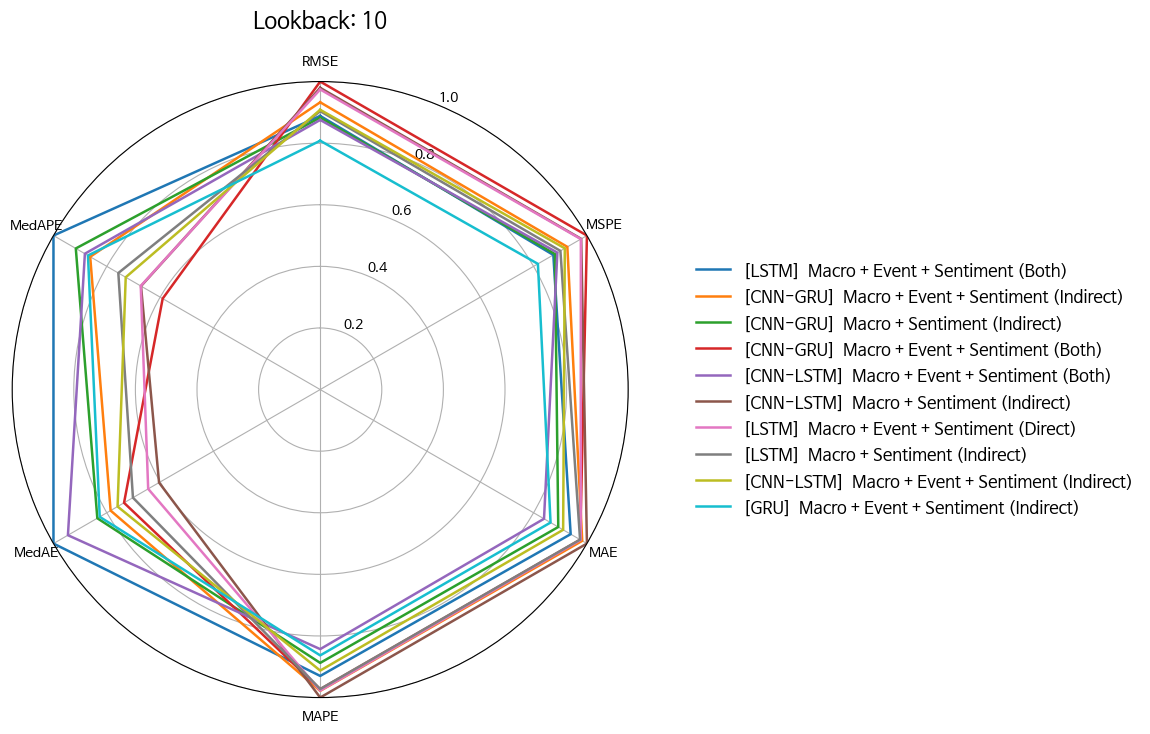


Top 10 by Radar Area:


,Model & Feature Case,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,Area of Radar
0,[CNN-LSTM] Macro + Sentiment (Both),0.9686,0.9681,0.9907,0.9890,1.0000,1.0000,2.5263
1,[CNN-GRU] Macro + Event + Sentiment (Both),1.0000,1.0000,1.0000,1.0000,0.9323,0.9405,2.4897
2,[LSTM] Macro + Sentiment (Direct),0.9598,0.9589,0.9965,0.9938,0.9837,0.9588,2.4713
3,[LSTM] Macro Only,0.9688,0.9689,0.9814,0.9801,0.9455,0.9609,2.4326
4,[CNN-LSTM] Macro + Sentiment (Direct),0.9548,0.9556,0.9792,0.9778,0.9280,0.9067,2.3470
5,[LSTM] Macro + Event + Sentiment (Direct),0.9798,0.9858,0.9727,0.9749,0.9085,0.8671,2.3365
6,[CNN-GRU] Macro + Sentiment (Indirect),0.9467,0.9460,0.9858,0.9847,0.9153,0.8646,2.2994
7,[CNN-LSTM] Macro + Event,0.9333,0.9395,0.9298,0.9300,0.9730,0.9363,2.2971
8,[LSTM] Macro + Sentiment (Both),0.9416,0.9429,0.9558,0.9541,0.9231,0.9204,2.2941
9,[LSTM] Macro + Sentiment (Indirect),0.9616,0.9650,0.9700,0.9696,0.8581,0.8467,2.2418


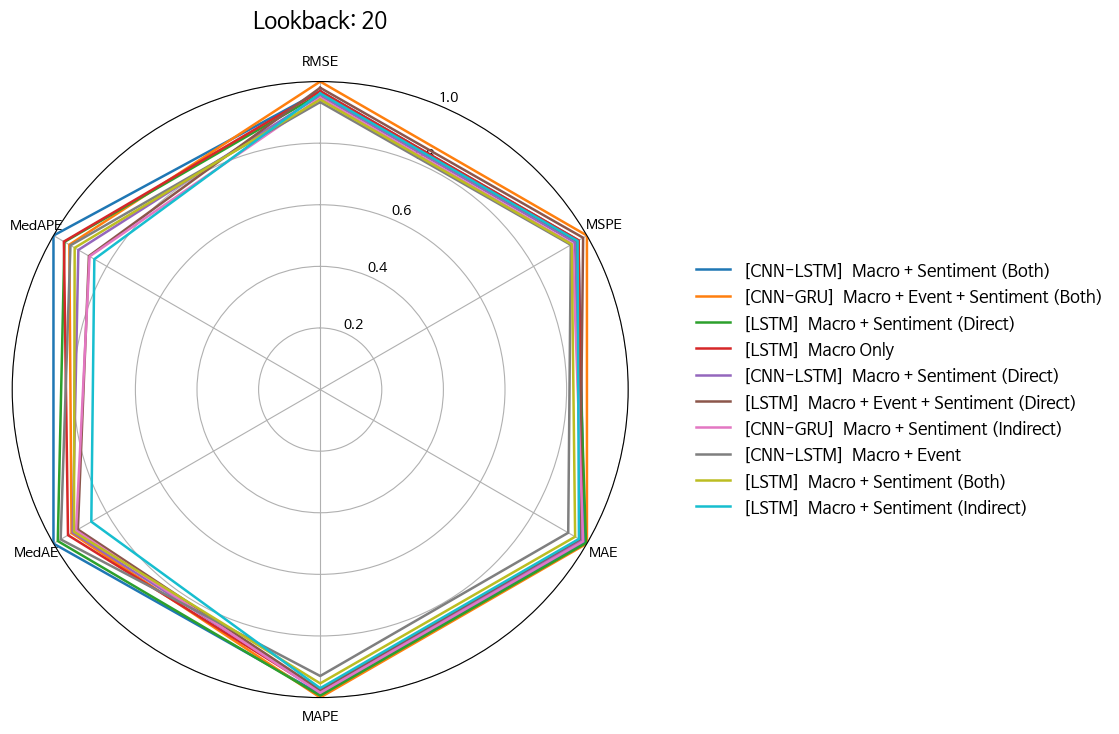


Top 10 by Radar Area:


,Model & Feature Case,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,Area of Radar
0,[CNN-GRU] Macro + Event + Sentiment (Direct),0.8584,0.8411,1.0000,1.0000,1.0000,1.0000,2.3476
1,[LSTM] Macro + Event + Sentiment (Indirect),1.0000,1.0000,0.9773,0.9839,0.5995,0.5768,1.9275
2,[LSTM] Macro Only,0.8183,0.8030,0.9851,0.9865,0.6217,0.7101,1.7562
3,[CNN-GRU] Macro + Event + Sentiment (Indirect),0.8175,0.8079,0.9680,0.9713,0.6332,0.6214,1.6884
4,[GRU] Macro + Event + Sentiment (Both),0.8121,0.7987,0.9848,0.9852,0.5750,0.5813,1.6360
5,[CNN-GRU] Macro + Event + Sentiment (Both),0.8677,0.8595,0.9332,0.9370,0.5125,0.5496,1.5853
6,[CNN-LSTM] Macro + Sentiment (Direct),0.8957,0.9030,0.9213,0.9298,0.5315,0.4513,1.5744
7,[LSTM] Macro + Event + Sentiment (Both),0.9509,0.9495,0.9531,0.9584,0.3856,0.3446,1.5379
8,[LSTM] Macro + Event + Sentiment (Direct),0.8005,0.7987,0.9216,0.9244,0.5009,0.4505,1.4188
9,[LSTM] Macro + Sentiment (Direct),0.6956,0.6905,0.8829,0.8862,0.6704,0.5889,1.4163


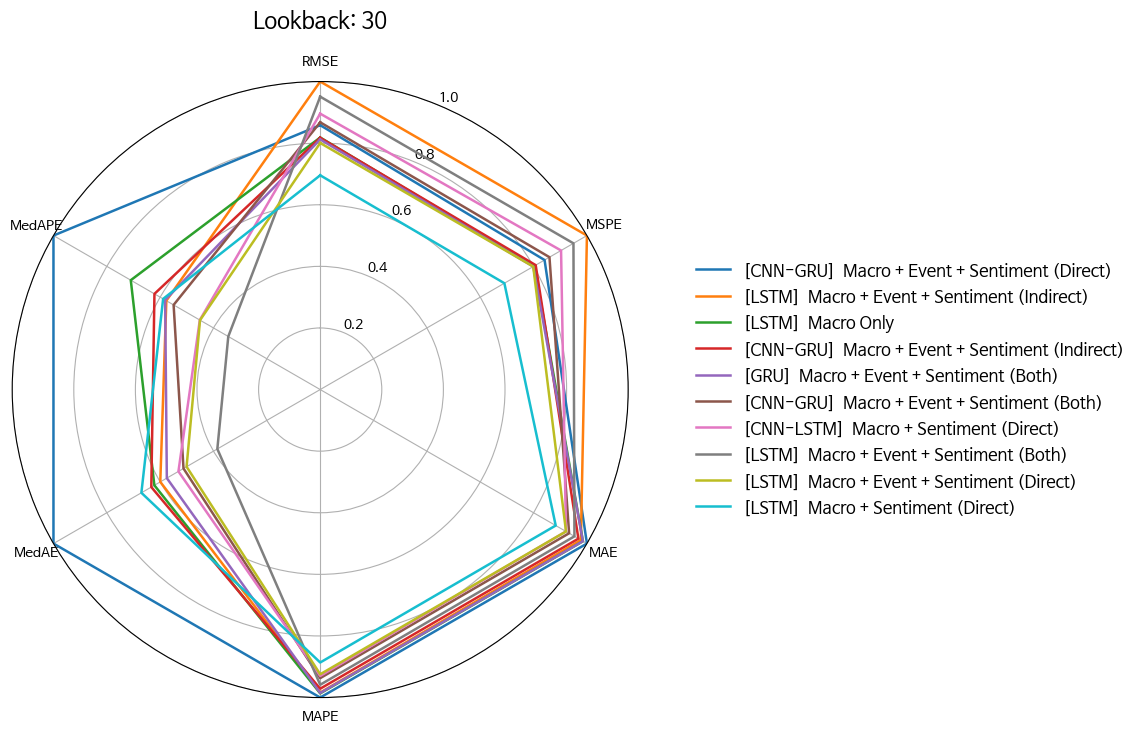


Top 10 by Radar Area:


,Model & Feature Case,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,Area of Radar
0,[CNN-LSTM] Macro + Sentiment (Both),1.0000,1.0000,0.9722,0.9730,0.7601,0.7814,2.1794
1,[LSTM] Macro + Sentiment (Both),0.9967,0.9957,1.0000,1.0000,0.7046,0.5456,2.0010
2,[CNN-LSTM] Macro + Sentiment (Direct),0.9252,0.9228,0.9138,0.9123,0.7174,0.7089,1.8834
3,[CNN-LSTM] Macro Only,0.9212,0.9271,0.9164,0.9182,0.8349,0.5812,1.8760
4,[LSTM] Macro + Sentiment (Indirect),0.8876,0.8765,0.9458,0.9422,0.7362,0.6682,1.8519
5,[GRU] Macro + Event + Sentiment (Direct),0.6908,0.6659,0.8471,0.8381,0.9822,1.0000,1.8318
6,[CNN-LSTM] Macro + Event,0.8249,0.8076,0.8876,0.8798,0.8185,0.6528,1.7134
7,[LSTM] Macro + Event + Sentiment (Both),0.9421,0.9584,0.8438,0.8478,0.5165,0.3795,1.4802
8,[GRU] Macro + Event + Sentiment (Indirect),0.5799,0.5703,0.7342,0.7271,1.0000,0.8671,1.4637
9,[CNN-LSTM] Macro + Event + Sentiment (Direct),0.7228,0.7264,0.7553,0.7570,0.8715,0.6527,1.4487


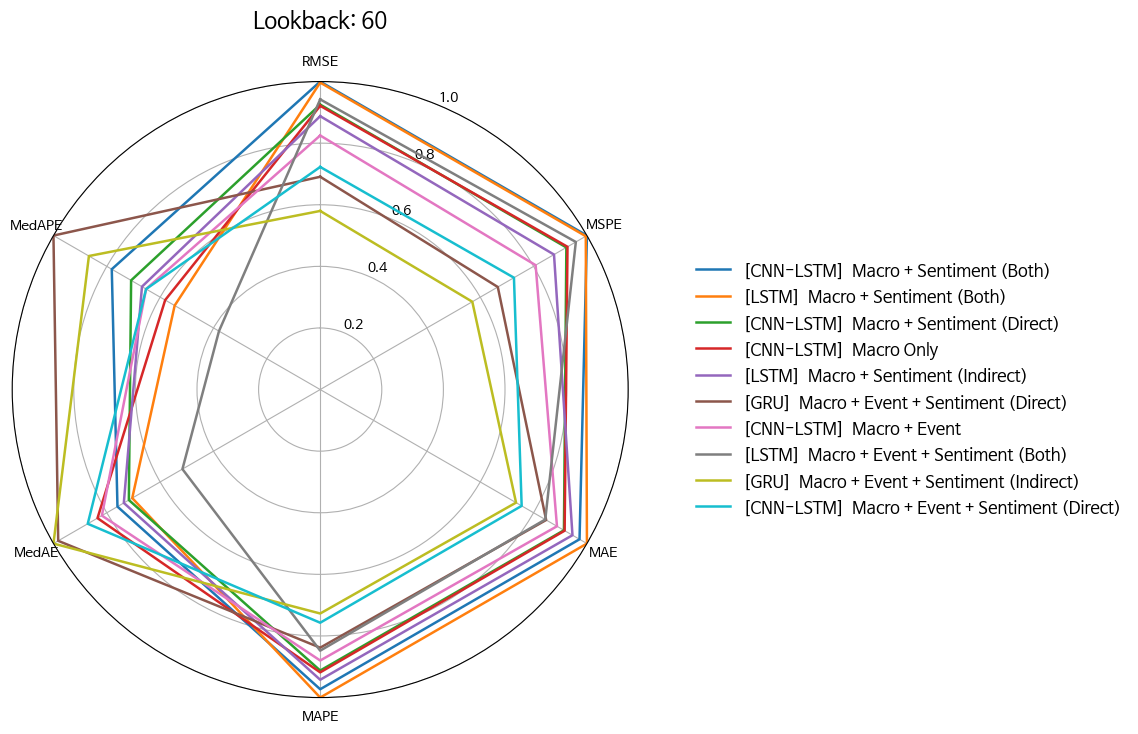


Top 10 by Radar Area:


,Model & Feature Case,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,Area of Radar
0,[CNN-LSTM] Macro Only,1.0000,1.0000,1.0000,1.0000,0.7373,0.7399,2.1749
1,[LSTM] Macro + Event,0.8382,0.8603,0.8497,0.8552,1.0000,1.0000,2.1098
2,[LSTM] Macro + Sentiment (Direct),0.8403,0.8522,0.9860,0.9852,0.7684,0.8783,2.0342
3,[CNN-GRU] Macro + Sentiment (Indirect),0.8731,0.8871,0.8587,0.8632,0.8253,0.9610,2.0014
4,[CNN-GRU] Macro + Event,0.8841,0.8995,0.8380,0.8411,0.7420,0.8256,1.8275
5,[CNN-GRU] Macro + Sentiment (Both),0.8320,0.8628,0.8467,0.8560,0.6976,0.6974,1.6614
6,[CNN-GRU] Macro + Event + Sentiment (Both),0.8103,0.8251,0.9228,0.9230,0.6171,0.6569,1.6407
7,[GRU] Macro + Event,0.7329,0.7681,0.6860,0.6937,0.8827,0.9859,1.6329
8,[LSTM] Macro + Event + Sentiment (Both),0.6819,0.7165,0.6899,0.6927,0.8962,0.8674,1.4941
9,[CNN-LSTM] Macro + Sentiment (Indirect),0.9593,0.9743,0.9493,0.9582,0.3554,0.2253,1.4747


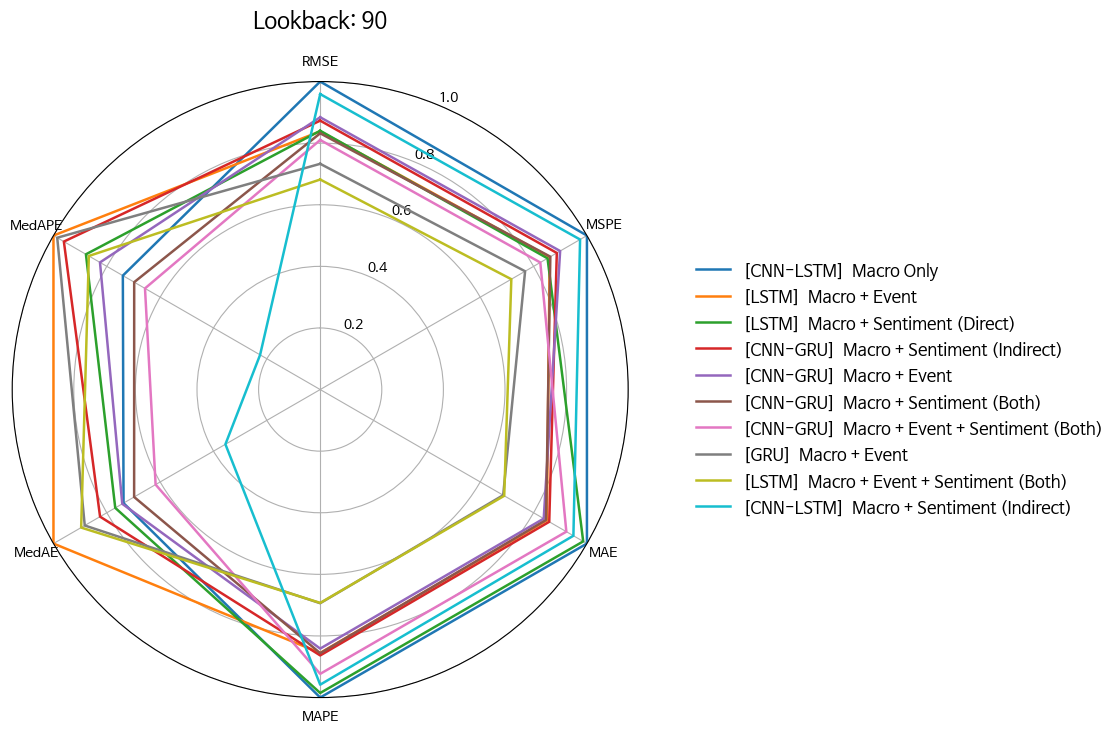

In [4]:
# Visualization
for lookback in sorted(df.Lookback.unique()):
    df_sub = df[df.Lookback == lookback]
    plot_radarchart(df_sub, metric_colnames=METRIC_COLNAMES,
                    label_colname=LABEL_COLNAME, 
                    scaling=SCALING, top_ranking=TOP_RANKING,
                    title='Lookback: '+str(np.unique(df_sub.Lookback)[0]))